# Pretraining datasets: from a name on the Hub to batches

**The whole idea in one sentence:** a pretraining dataset is a very long list of
documents, and everything here is about getting that list — from wherever it lives,
in whatever format — into a flat file of token ids **exactly once**, in a way you
can prove afterwards is the file you think it is.

[preprocessing.ipynb](preprocessing.ipynb) built the packer: text in, shards out,
batches back. This notebook is the layer above it. Which corpus? How much of it?
What format does it arrive in? How do you hold some out for validation without
fooling yourself? And what is the one command that does all of it in this repo?

By the end you'll have:

- a map of the corpora people actually pretrain on, and how big each one is
- worked out **how many tokens your model needs**, and found that for a small model
  most of its parameters are the embedding table
- seen that a "source" is nothing more than something you can loop over for strings
- read the same corpus from `.txt`, `.jsonl` and `.parquet`
- split off a validation set three wrong ways — **each of which runs without error
  and reports a validation loss that is a lie** — and then the right way
- written a data config, packed it with one command, run the command again and
  watched it do nothing, then changed the config and watched it refuse
- read real batches back, and worked out how many steps one epoch is

In [1]:
import hashlib
import json
import random
import shutil
import tempfile
from pathlib import Path

import numpy as np

np.set_printoptions(linewidth=110)
WORK = Path(tempfile.mkdtemp(prefix="litterbox-datasets-"))     # everything this notebook writes

try:
    import matplotlib
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False
    print("matplotlib not installed - plot cells will print a note instead (uv sync --extra demo)")

SURFACE, INK, INK2, GRID, BLUE, ORANGE = "#fcfcfb", "#1f1e1d", "#6b6a63", "#e8e7e3", "#2a78d6", "#eb6834"

def style(ax):
    ax.set_facecolor(SURFACE); ax.set_axisbelow(True)
    ax.grid(color=GRID, lw=0.6)
    ax.tick_params(colors=INK2, labelsize=8)
    for s in ax.spines.values():
        s.set_visible(False)

---
## 1. What people pretrain on

Pretraining text is nearly all *web text that someone else has already cleaned*. You
almost never scrape your own. The work that matters — language filtering,
deduplication, quality classifiers, removing boilerplate — has been done, published,
and put on the HuggingFace Hub. The corpora below are the ones you will keep
running into. Token counts are approximate and depend on the tokenizer.

In [2]:
CORPORA = [
    # name,               Hub id,                          tokens,  what it is
    ("TinyStories",       "roneneldan/TinyStories",          0.47e9, "synthetic children's stories, tiny vocabulary"),
    ("Wikipedia (en)",    "wikimedia/wikipedia",              4.5e9, "encyclopedia; clean, narrow in style"),
    ("OpenWebText",       "Skylion007/openwebtext",             9e9, "open reproduction of GPT-2's WebText"),
    ("FineWeb-Edu 10BT",  "HuggingFaceFW/fineweb-edu",         10e9, "a sample of FineWeb-Edu, sized for ~100M models"),
    ("Cosmopedia",        "HuggingFaceTB/cosmopedia",          25e9, "synthetic textbooks and articles"),
    ("C4 (en)",           "allenai/c4",                       156e9, "Common Crawl, lightly filtered (T5's corpus)"),
    ("SlimPajama",        "cerebras/SlimPajama-627B",         627e9, "deduplicated RedPajama: web, code, books, papers"),
    ("FineWeb-Edu",       "HuggingFaceFW/fineweb-edu",        1.3e12, "FineWeb filtered by an educational-quality classifier"),
    ("Dolma",             "allenai/dolma",                      3e12, "OLMo's corpus: web, code, papers, books, social"),
    ("FineWeb",           "HuggingFaceFW/fineweb",             15e12, "96 Common Crawl dumps, filtered and deduplicated"),
]

def human(n):
    for unit, size in (("T", 1e12), ("B", 1e9), ("M", 1e6)):
        if n >= size:
            return f"{n / size:,.3g}{unit}"
    return f"{n:,.0f}"

for name, hub, tokens, what in CORPORA:
    print(f"{name:18} {human(tokens):>6} tokens   {hub:30} {what}")

TinyStories          470M tokens   roneneldan/TinyStories         synthetic children's stories, tiny vocabulary
Wikipedia (en)       4.5B tokens   wikimedia/wikipedia            encyclopedia; clean, narrow in style
OpenWebText            9B tokens   Skylion007/openwebtext         open reproduction of GPT-2's WebText
FineWeb-Edu 10BT      10B tokens   HuggingFaceFW/fineweb-edu      a sample of FineWeb-Edu, sized for ~100M models
Cosmopedia            25B tokens   HuggingFaceTB/cosmopedia       synthetic textbooks and articles
C4 (en)              156B tokens   allenai/c4                     Common Crawl, lightly filtered (T5's corpus)
SlimPajama           627B tokens   cerebras/SlimPajama-627B       deduplicated RedPajama: web, code, books, papers
FineWeb-Edu          1.3T tokens   HuggingFaceFW/fineweb-edu      FineWeb filtered by an educational-quality classifier
Dolma                  3T tokens   allenai/dolma                  OLMo's corpus: web, code, papers, books, social
FineWeb  

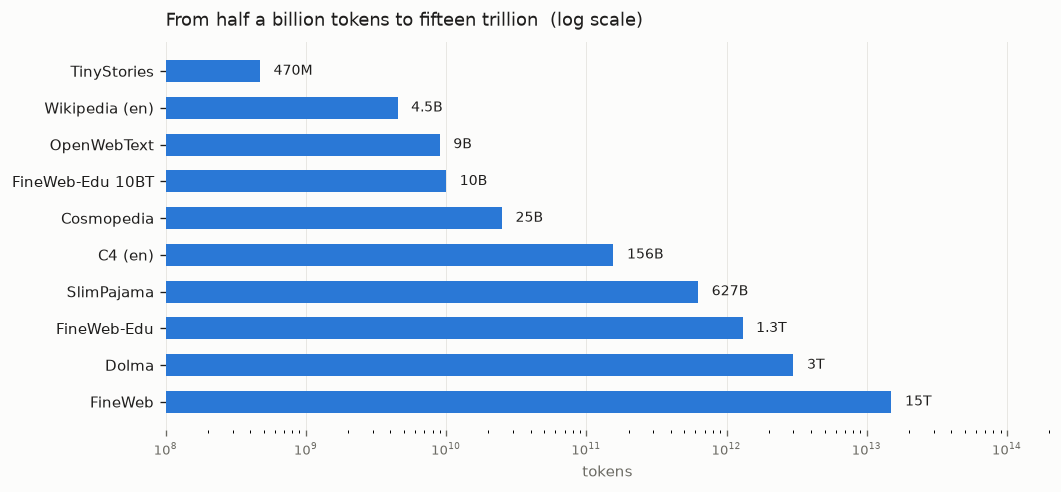

In [3]:
if HAVE_MPL:
    names = [c[0] for c in CORPORA][::-1]
    toks = [c[2] for c in CORPORA][::-1]
    fig, ax = plt.subplots(figsize=(9.5, 4.2), dpi=120)
    fig.patch.set_facecolor(SURFACE); style(ax); ax.grid(axis="y", visible=False)
    ax.barh(names, toks, color=BLUE, height=0.6)
    for i, t in enumerate(toks):
        ax.text(t * 1.25, i, human(t), va="center", color=INK, fontsize=8.5)
    ax.set_xscale("log"); ax.set_xlim(1e8, 2e14)
    ax.set_title("From half a billion tokens to fifteen trillion  (log scale)",
                 color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xlabel("tokens", color=INK2, fontsize=9)
    ax.tick_params(axis="y", labelsize=9, colors=INK)
    plt.show()
else:
    print("(plot skipped)")

Three things worth noticing.

**The scale is logarithmic, and it has to be.** FineWeb is thirty thousand times
TinyStories. No single pipeline design is comfortable across that whole range, which
is why this repo targets the bottom half — single machine, local disk — and defers
the rest.

**The big ones ship a sample.** FineWeb-Edu offers `sample-10BT`, `sample-100BT` and
`sample-350BT`. That is the thing to reach for: a random slice of a well-filtered
corpus beats the whole of a worse one.

**Two of them are synthetic.** TinyStories and Cosmopedia were *written by a language
model*. TinyStories in particular was built to answer one question — how small can a
model be and still produce coherent English? — by restricting the vocabulary to what
a young child knows. That makes it the ideal first target: models of 1–30M parameters
learn it, and a broken model shows up as nonsense in minutes.

---
## 2. How much do you need?

The rule of thumb from the Chinchilla paper (Hoffmann et al., 2022): for a fixed
compute budget, a model wants about **20 tokens per parameter**. Fewer and you've
built a model too big for your data; many more and a smaller model would have done
as well for less. It's a guide to proportion, not a law — small models are routinely
trained far past it because inference is what you pay for later.

So first: how many parameters? A dense decoder block is four attention matrices and
three SwiGLU matrices, and with this repo's defaults that comes to `12 · d²` per
layer. Then there's the embedding table.

In [4]:
VOCAB = 50_304          # GPT-2's 50,257, padded up to a multiple of 64

def count_params(d_model, n_layers, vocab=VOCAB):
    attention = 4 * d_model * d_model                      # q, k, v, o  (multi-head)
    mlp = 3 * d_model * (8 * d_model // 3)                 # SwiGLU at 8/3 width  = 8 d^2
    blocks = n_layers * (attention + mlp)
    embedding = vocab * d_model                            # tied with the LM head: counted once
    return blocks, embedding

print(f"{'shape':>16} {'blocks':>9} {'embedding':>10} {'total':>8} {'embed share':>12} {'tokens wanted':>14} {'TinyStories epochs':>19}")
for d_model, n_layers in ((128, 4), (256, 6), (384, 8), (512, 8), (768, 12)):
    blocks, emb = count_params(d_model, n_layers)
    total = blocks + emb
    wanted = 20 * total
    print(f"{f'd={d_model}, L={n_layers}':>16} {human(blocks):>9} {human(emb):>10} {human(total):>8} "
          f"{emb / total:>11.0%} {human(wanted):>14} {wanted / 0.47e9:>18.1f}x")

           shape    blocks  embedding    total  embed share  tokens wanted  TinyStories epochs
      d=128, L=4   785,920      6.44M    7.22M         89%           144M                0.3x
      d=256, L=6     4.72M      12.9M    17.6M         73%           352M                0.7x
      d=384, L=8     14.2M      19.3M    33.5M         58%           669M                1.4x
      d=512, L=8     25.2M      25.8M    50.9M         51%          1.02B                2.2x
     d=768, L=12     84.9M      38.6M     124M         31%          2.47B                5.3x


Read the *embed share* column. **For a small model, most of the parameters are the
embedding table.** A `d=256` model is 73% lookup table: 50,000 rows it mostly doesn't
need, because a children's-story corpus uses a few thousand distinct words. This is
the strongest argument for training your own small-vocabulary tokenizer on a small
corpus, and it's why the TinyStories paper reports models by their *non-embedding*
size.

Read the last column too. TinyStories is about one Chinchilla-budget for a model
somewhere between `d=256` and `d=384`. Below that you have more data than you need; at `d=768` you'd
loop over it five times, which for a corpus this repetitive means memorising it. The
100M-class config in this repo is sized for FineWeb-Edu's 10B sample instead.

---
## 3. A source is anything you can loop over

Here's the entire interface a corpus has to satisfy in this repo:

> **an iterable of strings, one string per document.**

That's it. Not a class, not a schema. A list works. A generator works. It's a low
enough bar that text from the Hub, from disk, or from a test fixture all look the
same to the packer.

The one requirement that isn't optional is **laziness**. A real corpus doesn't fit in
memory, so a source must hand over documents one at a time and never build the whole
list. Write one by hand:

In [5]:
def stories(n):
    # a lazy source: nothing exists until someone asks for the next document
    animals, things = ["cat", "dog", "bird", "frog", "bear"], ["ball", "hat", "kite", "cake", "boat"]
    rng = random.Random(0)
    for i in range(n):
        a, t = rng.choice(animals), rng.choice(things)
        yield (f"Once upon a time there was a little {a} who found a {t}. "
               f"The {a} loved the {t} very much. One day the {t} was lost, and the {a} was sad. "
               f"Then a friend helped the {a} look, and they found the {t} together. The end. (story {i})")

source = stories(1_000_000)               # a million documents, and zero memory used so far
print(type(source).__name__, "->", next(source)[:96], "...")

generator -> Once upon a time there was a little frog who found a cake. The frog loved the cake very much. On ...


A million stories "exist" and none have been built. The packer pulls them one by one,
tokenizes, writes, and forgets.

The repo registers four sources by name, so that a config file can ask for one:

In [6]:
from litterbox.data import available_sources, build_source

print("registered sources:", available_sources())
print()
print(next(build_source({"type": "text", "text": ["a document held in memory", "another"]})))

registered sources: ['files', 'huggingface', 'jsonl', 'text']

a document held in memory


| source | reads | use it for |
|---|---|---|
| `text` | strings in memory | tests, tiny experiments |
| `files` | local files by glob — one document per file, or per line | your own plain text |
| `jsonl` | JSON Lines, one chosen field per record | most cleaning tools' output |
| `huggingface` | anything the `datasets` library can open | the Hub — and, as you'll see, local Parquet |

Adding a fifth is one decorated generator function. Nothing downstream changes.

---
## 4. The three formats text arrives in

Make a small corpus and write it out the three ways you'll meet in the wild.

In [7]:
corpus = list(stories(600))
raw = WORK / "raw"; raw.mkdir()

# 1. plain text - one document per file
(raw / "txt").mkdir()
for i, doc in enumerate(corpus):
    (raw / "txt" / f"{i:04d}.txt").write_text(doc)

# 2. JSON Lines - one JSON object per line, text in a named field, metadata alongside
with (raw / "stories.jsonl").open("w") as f:
    for i, doc in enumerate(corpus):
        f.write(json.dumps({"id": i, "text": doc, "source": "demo"}) + "\n")

# 3. Parquet - columnar, compressed, what the Hub serves
try:
    import pyarrow as pa, pyarrow.parquet as pq
    pq.write_table(pa.table({"id": list(range(len(corpus))), "text": corpus}), raw / "stories.parquet")
    HAVE_PARQUET = True
except ImportError:
    HAVE_PARQUET = False
    print("pyarrow not installed - skipping the Parquet file (uv sync --extra demo)")

for p in sorted(raw.iterdir()):
    size = sum(f.stat().st_size for f in p.rglob("*") if f.is_file()) if p.is_dir() else p.stat().st_size
    print(f"{p.name:18} {size / 1e3:>8.1f} kB" + ("   (600 files)" if p.is_dir() else ""))

stories.jsonl         163.3 kB
stories.parquet        25.6 kB
txt                   138.2 kB   (600 files)


Same 600 documents. Parquet is a fraction of the size because it's columnar and
compressed — which, along with being readable in chunks without parsing the whole
file, is why the Hub converts every dataset to it.

Now read each one back through a registered source:

In [8]:
def first_and_count(cfg):
    docs = list(build_source(cfg))
    return len(docs), docs[0][:60]

readers = {
    "files": {"type": "files", "pattern": "*.txt", "root": str(raw / "txt")},
    "jsonl": {"type": "jsonl", "pattern": "*.jsonl", "root": str(raw), "text_key": "text"},
}
if HAVE_PARQUET:
    try:
        import datasets
        datasets.disable_progress_bars()
        # No Parquet source of our own: the `datasets` library has generic loaders, and the
        # huggingface source passes extra arguments straight through. `name: json` with
        # data_files="*.jsonl.zst" reads compressed JSON Lines the same way.
        readers["parquet"] = {"type": "huggingface", "name": "parquet",
                              "data_files": str(raw / "stories.parquet"), "streaming": False}
    except ImportError:
        print("`datasets` not installed - skipping the Parquet reader")

for name, cfg in readers.items():
    n, head = first_and_count(cfg)
    print(f"{name:8} {n} documents   {head!r}...")

files    600 documents   'Once upon a time there was a little frog who found a cake. T'...


jsonl    600 documents   'Once upon a time there was a little frog who found a cake. T'...


parquet  600 documents   'Once upon a time there was a little frog who found a cake. T'...


Three formats, one interface, identical documents. From here on nothing cares which
one it was.

---
## 5. Holding out a validation set — three ways to fool yourself

You need validation text the model never trained on, or you cannot tell *learning*
from *memorising*. Some corpora ship a validation split (TinyStories does). Many
don't (FineWeb-Edu doesn't), and then you carve one out.

Real web text has a property that makes this harder than it looks: **it repeats.**
Boilerplate, reposts, licence text, quoted articles. So build a corpus that does too —
600 stories, a third of them appearing twice:

In [9]:
rng = random.Random(1)
with_dupes = corpus + rng.sample(corpus, 200)
rng.shuffle(with_dupes)
print(f"{len(with_dupes)} documents, {len(set(with_dupes))} distinct")

def leaked(train, val):
    # validation documents whose exact text is also in the training set
    seen = set(train)
    return sum(d in seen for d in val)

800 documents, 600 distinct


### Wrong way 1: the last 10%

The obvious thing. Take the final tenth of the documents as validation.

In [10]:
cut = int(0.9 * len(with_dupes))
train, val = with_dupes[:cut], with_dupes[cut:]
print(f"validation documents: {len(val)}   of which also in training: {leaked(train, val)}  "
      f"({leaked(train, val) / len(val):.0%})")

validation documents: 80   of which also in training: 39  (49%)


A large share of the "held-out" set is text the model trained on. Its validation loss
on those documents measures recall, not generalisation — and it will look *good*,
which is the worst kind of wrong.

### Wrong way 2: slice the packed token stream

Tempting once everything is one long array of tokens: train on the first 90%,
validate on the rest. But the cut lands wherever it lands —

In [11]:
stream = " ".join(corpus[:50])
cut = int(0.9 * len(stream))
print("training ends with  :", repr(stream[cut - 60 : cut]))
print("validation begins   :", repr(stream[cut : cut + 60]))

training ends with  : ' bear look, and they found the kite together. The end. (stor'
validation begins   : 'y 44) Once upon a time there was a little frog who found a b'


— in the middle of a document. The model trained on the first half of that story and
is validated on the second half. With long documents and a small validation set, a
meaningful part of validation is the *continuation of training text*. This is why the
repo's `pack()` takes a `split` name and wants disjoint **documents** per split,
decided before anything is tokenized.

### Wrong way 3: a seeded coin flip

Assign whole documents at random, with a seed so it's reproducible. That fixes way 2
— no document is cut in half — and it looks like it should fix the rest:

In [12]:
def coin_flip_split(docs, p=0.1, seed=0):
    r = random.Random(seed)
    flips = [r.random() < p for _ in docs]              # one flip per *position*
    return [d for d, f in zip(docs, flips) if not f], [d for d, f in zip(docs, flips) if f]

train, val = coin_flip_split(with_dupes)
print(f"validation: {len(val)} documents, of which also in training: {leaked(train, val)}")

_, val_again = coin_flip_split(with_dupes[1:])          # the same corpus, first document dropped
print(f"same seed, one document fewer: {len(val_again)} validation documents, "
      f"{len(set(val) & set(val_again))} in common with before")

validation: 92 documents, of which also in training: 42
same seed, one document fewer: 92 validation documents, 17 in common with before


Two failures. Duplicates still leak, because a flip per *position* knows nothing about
what the text says: two copies of one story get two independent flips. And "seeded"
made it reproducible only for the **exact same documents in the exact same order**. Drop one document from the front — or let a streaming dataset hand you shards
in a different order, or add a new crawl to the corpus — and every later coin flip
shifts. You get a different validation set, and documents that were validation last
month are training data now. Any comparison between the two runs is contaminated.

### The right way: ask the document

Don't flip a coin *per position*. Hash the **text**, and let the hash decide:

In [13]:
def side(text, val_fraction=0.1, seed=0):
    digest = hashlib.blake2b(text.encode(), digest_size=8, salt=seed.to_bytes(8, "little")).digest()
    return "val" if int.from_bytes(digest, "little") < val_fraction * 2**64 else "train"

for d in corpus[:4]:
    print(side(d), "<-", d[-12:])

train = [d for d in with_dupes if side(d) == "train"]
val = [d for d in with_dupes if side(d) == "val"]
print(f"\n{len(train)} train + {len(val)} val = {len(train) + len(val)}   leaked: {leaked(train, val)}")

again = {d for d in with_dupes[1:] if side(d) == "val"}
print("same validation set after dropping a document:", again == set(val) - {with_dupes[0]})

train <- d. (story 0)
train <- d. (story 1)
train <- d. (story 2)
train <- d. (story 3)

722 train + 78 val = 800   leaked: 0
same validation set after dropping a document: True


**That's the entire trick:** a document's side is a function of *the document*, and
of nothing else. Three properties fall out for free:

- **Reproducible anywhere** — no RNG state, no dependence on order or on what came
  before. Same document, same side, on every machine, forever, even as the corpus grows.
- **Exact duplicates can't straddle** — two copies hash identically, so they land
  together. Zero leaked, by construction.
- **Stateless** — each side is its own lazy pass, so nothing is buffered.

The price: the realised fraction is approximate (it's binomial), and the corpus is
read once per side. That's `litterbox.data.holdout`:

In [14]:
from litterbox.data import holdout

val_packaged = set(holdout(with_dupes, val_fraction=0.1, keep="val"))
train_packaged = set(holdout(with_dupes, val_fraction=0.1, keep="train"))
print(f"{len(train_packaged)} distinct train, {len(val_packaged)} distinct val, overlap {len(train_packaged & val_packaged)}")

539 distinct train, 61 distinct val, overlap 0


(It catches *exact* duplicates only. Near-duplicates — the same article with a
different footer — need MinHash-style deduplication, which the curated Hub corpora
have already had done to them. That's another reason to start from those.)

---
## 6. One config, one command

Everything so far — which source, which tokenizer, which splits, where it goes — is a
handful of decisions. In this repo they live in one small YAML file under
`configs/data/`, and one command turns that file into a directory a training run reads.

In [15]:
config_path = WORK / "stories.yaml"
config_path.write_text(f'''
description: the demo corpus, byte-level tokenizer
out_dir: {WORK / "packed"}

tokenizer: {{type: byte}}

source: {{type: files, pattern: "*.txt", root: {raw / "txt"}}}

holdout: {{val_fraction: 0.1, seed: 0}}
''')
print(config_path.read_text())


description: the demo corpus, byte-level tokenizer
out_dir: /var/folders/6f/nlxmh98x0gs39pbn_n9lt9jm0000gn/T/litterbox-datasets-hd5fpkbh/packed

tokenizer: {type: byte}

source: {type: files, pattern: "*.txt", root: /var/folders/6f/nlxmh98x0gs39pbn_n9lt9jm0000gn/T/litterbox-datasets-hd5fpkbh/raw/txt}

holdout: {val_fraction: 0.1, seed: 0}



In [16]:
from litterbox.data import load_data_config, prepare

cfg = load_data_config(config_path)
print("fingerprint:", cfg.fingerprint(), "\n")
meta = prepare(cfg)

fingerprint: dd4de2545f2a6ebc 

/var/folders/6f/nlxmh98x0gs39pbn_n9lt9jm0000gn/T/litterbox-datasets-hd5fpkbh/packed: packing with byte (vocab 256)
  train:        539 docs         124,196 tokens  1 shard(s)  0.0s
    val:         61 docs          14,042 tokens  1 shard(s)  0.0s


In [17]:
for p in sorted(Path(cfg.out_dir).iterdir()):
    print(f"{p.name:16} {p.stat().st_size:>9,} bytes")

dataset.json           611 bytes
meta.json              558 bytes
train_0000.bin     248,392 bytes
train_docs.bin       4,312 bytes
val_0000.bin        28,084 bytes
val_docs.bin           488 bytes


Four kinds of file:

- `train_0000.bin`, `val_0000.bin` — the tokens, as a flat array. Nothing else.
- `*_docs.bin` — where each document starts. Nothing reads it yet; it's there because
  it's impossible to recover later without repacking.
- `meta.json` — the tokenizer, the dtype, the shard list. What makes the `.bin` files
  *readable*.
- `dataset.json` — the config that produced all of the above, and its fingerprint.
  What makes the directory *provable*.

From a shell it's the same thing:

```bash
litterbox-pack configs/data/tinystories.yaml
litterbox-pack configs/data/tinystories.yaml --limit 2000 --out data/tinystories-smoke
```

### Break it on purpose: run it twice, then change your mind

Packing is expensive and a training script will call it on every launch. So running
it again must be free:

In [18]:
prepare(cfg);

/var/folders/6f/nlxmh98x0gs39pbn_n9lt9jm0000gn/T/litterbox-datasets-hd5fpkbh/packed: up to date (fingerprint dd4de2545f2a6ebc), nothing to do


Now the dangerous case. You edit the config — a different tokenizer, a different
holdout fraction — and point it at the **same directory**. If `prepare` quietly reused
what was there, you'd train on tokens from the old config while your experiment notes
describe the new one. Nothing would raise. The loss curve would just be for a
different experiment than the one you think you ran.

In [19]:
changed = load_data_config(config_path, limit=100)
print("new fingerprint:", changed.fingerprint(), " (was", cfg.fingerprint() + ")\n")
try:
    prepare(changed)
except FileExistsError as e:
    print("refused:", e)

new fingerprint: e014b86294314485  (was dd4de2545f2a6ebc)

refused: /var/folders/6f/nlxmh98x0gs39pbn_n9lt9jm0000gn/T/litterbox-datasets-hd5fpkbh/packed already exists and was packed from a different config. Refusing to mix datasets in one directory. Re-run with force=True / --force to delete it and repack, or change out_dir.


It refuses. `force=True` (or `--force`) deletes and repacks — and will only delete a
directory that is recognisably a packed dataset, so a typo in `out_dir` can't remove
something else.

The config is strict in the same spirit. A misspelled key doesn't fall back to a
default; it fails at load:

In [20]:
from pydantic import ValidationError

bad = WORK / "typo.yaml"
bad.write_text(config_path.read_text().replace("holdout:", "hold_out:"))
try:
    load_data_config(bad)
except ValidationError as e:
    print(str(e).split("For further")[0].rstrip())

1 validation error for DataConfig
hold_out
  Extra inputs are not permitted [type=extra_forbidden, input_value={'val_fraction': 0.1, 'seed': 0}, input_type=dict]


---
## 7. Reading it back for training

The training loop never sees documents, sources, or formats. It sees this:

In [21]:
from litterbox.data import PackedDataset
from litterbox.data.tokenizer import build_tokenizer

tok = build_tokenizer(cfg.tokenizer)
train_ds = PackedDataset(cfg.out_dir, seq_len=48, split="train", tokenizer=tok)
val_ds = PackedDataset(cfg.out_dir, seq_len=48, split="val", tokenizer=tok)
print(train_ds); print(val_ds)

x, y = train_ds.get_batch(batch_size=3, step=0)
print(f"\nx {tuple(x.shape)} {x.dtype}    y {tuple(y.shape)}")
print("input :", repr(tok.decode(x[0].tolist())))
print("target:", repr(tok.decode(y[0].tolist())))

<PackedDataset 'train' 124,196 tokens in 1 shard(s), uint16, tokenizer='byte'>
<PackedDataset 'val' 14,042 tokens in 1 shard(s), uint16, tokenizer='byte'>

x (3, 48) torch.int64    y (3, 48)
input : 'e cake very much. One day the cake was lost, and'
target: ' cake very much. One day the cake was lost, and '


The target is the input shifted one token left — that's the whole of "next-token
prediction". Passing `tokenizer=` makes the dataset check that these shards were
packed by that tokenizer and refuse otherwise.

Batches are a function of `(seed, step)`, not of how many times you've called
anything — so a run resumed at step 5,000 sees the batch an uninterrupted run would
have:

In [22]:
a, _ = train_ds.get_batch(3, step=5000)
b, _ = train_ds.get_batch(3, step=5000)
c, _ = train_ds.get_batch(3, step=5001)
print("step 5000 twice -> identical:", bool((a == b).all()), "   step 5001 -> different:", not bool((a == c).all()))

step 5000 twice -> identical: True    step 5001 -> different: True


And the arithmetic you'll want before launching anything — how long is an epoch?

In [23]:
def steps_per_epoch(n_tokens, batch_size, seq_len):
    return n_tokens // (batch_size * seq_len)

print(f"{'corpus':22} {'tokens':>8}   steps per epoch at  B=32 S=512   B=64 S=1024")
for name, tokens in (("this demo corpus", len(train_ds)), ("TinyStories", 474_000_000), ("FineWeb-Edu 10BT", 10_000_000_000)):
    print(f"{name:22} {human(tokens):>8}   {steps_per_epoch(tokens, 32, 512):>28,}   {steps_per_epoch(tokens, 64, 1024):>11,}")

corpus                   tokens   steps per epoch at  B=32 S=512   B=64 S=1024
this demo corpus        124,196                              7             1
TinyStories                474M                         28,930         7,232
FineWeb-Edu 10BT            10B                        610,351       152,587


(Windows are sampled at random offsets rather than walked in order, so an "epoch" here
means "as many tokens as the corpus holds", not "every token exactly once". At
pretraining scale you rarely complete one anyway.)

---
## 8. The real thing

If you've packed TinyStories (`litterbox-pack configs/data/tinystories.yaml` — a few
minutes, under a gigabyte), this section reads it. If not, it says so and moves on.

In [24]:
def find_repo_root():
    here = Path.cwd().resolve()
    for p in (here, *here.parents):
        if (p / "configs" / "data" / "tinystories.yaml").exists():
            return p
    return None

ROOT = find_repo_root()
real = None
if ROOT is not None:
    ts_cfg = load_data_config(ROOT / "configs" / "data" / "tinystories.yaml")
    for candidate in (ROOT / ts_cfg.out_dir, ROOT / "data" / "tinystories-smoke"):
        if (candidate / "dataset.json").exists():
            real = candidate
            break

if real is None:
    print("TinyStories is not packed on this machine. To pack it:\n\n"
          "    litterbox-pack configs/data/tinystories.yaml\n")
else:
    gpt2 = build_tokenizer(json.loads((real / "meta.json").read_text())["tokenizer"])
    ts = PackedDataset(real, seq_len=256, tokenizer=gpt2)
    print(real.relative_to(ROOT)); print(ts)
    info = json.loads((real / "meta.json").read_text())["splits"]
    for split, s in info.items():
        print(f"  {split:>5}: {s['n_documents']:>10,} documents  {s['n_tokens']:>13,} tokens  {len(s['shards'])} shard(s)")
    print("\n" + gpt2.decode(ts.read(0, 120).tolist()))

data/tinystories-gpt2
<PackedDataset 'train' 473,992,236 tokens in 5 shard(s), uint16, tokenizer='tiktoken:gpt2'>
  train:  2,119,719 documents    473,992,236 tokens  5 shard(s)
    val:     21,990 documents      4,765,918 tokens  1 shard(s)

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was


tokens per story: median 192, mean 224, 95th percentile 457, longest 1,270
   stories that fit whole in a window of  128:    4%
   stories that fit whole in a window of  256:   81%
   stories that fit whole in a window of  512:   97%
   stories that fit whole in a window of 1024:  100%


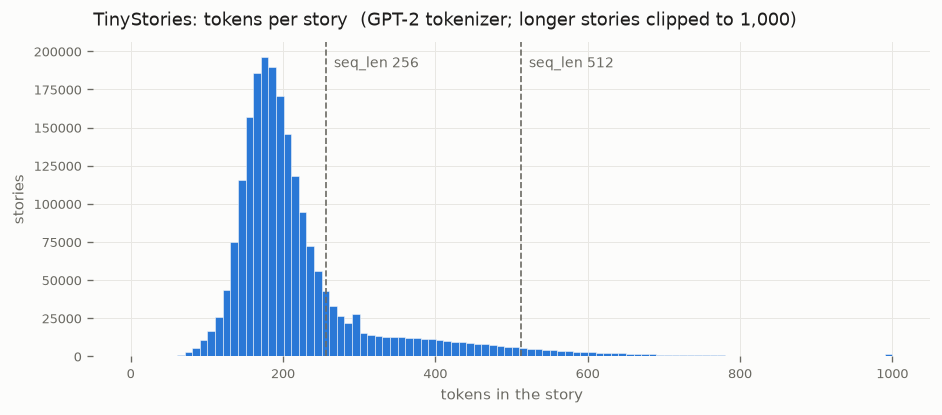

In [25]:
if real is not None:
    starts = np.fromfile(real / "train_docs.bin", dtype=np.int64)
    lengths = np.diff(starts)
    print(f"tokens per story: median {np.median(lengths):.0f}, mean {lengths.mean():.0f}, "
          f"95th percentile {np.percentile(lengths, 95):.0f}, longest {lengths.max():,}")
    for seq_len in (128, 256, 512, 1024):
        print(f"   stories that fit whole in a window of {seq_len:>4}: {(lengths <= seq_len).mean():>5.0%}")

    if HAVE_MPL:
        fig, ax = plt.subplots(figsize=(9, 3.4), dpi=120)
        fig.patch.set_facecolor(SURFACE); style(ax)
        ax.hist(np.clip(lengths, 0, 1000), bins=100, color=BLUE, edgecolor=SURFACE, linewidth=0.3)
        for seq_len in (256, 512):
            ax.axvline(seq_len, color=INK2, lw=1, ls="--")
            ax.annotate(f"seq_len {seq_len}", (seq_len, ax.get_ylim()[1] * 0.92), xytext=(5, 0),
                        textcoords="offset points", color=INK2, fontsize=8.5)
        ax.set_title("TinyStories: tokens per story  (GPT-2 tokenizer; longer stories clipped to 1,000)",
                     color=INK, fontsize=11, loc="left", pad=10)
        ax.set_xlabel("tokens in the story", color=INK2, fontsize=9)
        ax.set_ylabel("stories", color=INK2, fontsize=9)
        plt.show()
else:
    print("(skipped: TinyStories is not packed on this machine)")

That histogram is the most useful picture to have before choosing a `seq_len`. If most
documents are ~200 tokens, a window of 2,048 holds ten unrelated stories glued together
with end-of-text tokens between them — all of which the model can attend across. That's
normal and generally accepted (see *intra-document attention masking* in `DEFERRED.md`),
but it means a long window buys nothing on this corpus. `seq_len=256` or `512` is the
right size here, and it's also most of why a small model on TinyStories trains fast.

---
## 9. Straight from the Hub

The `huggingface` source streams: documents arrive as they're downloaded, nothing
lands on disk, and `limit` stops early. This is how you look at a corpus before
committing to a pack. (Needs the `datasets` package and a network connection; without
either it prints a note.)

In [26]:
try:
    hub = build_source({"type": "huggingface", "name": "roneneldan/TinyStories",
                        "split": "validation", "limit": 3})
    for i, doc in enumerate(hub):
        print(f"[{i}] {len(doc):>5} chars   {doc[:110]!r}...")
except Exception as e:                                   # offline, or `datasets` missing
    print(f"(skipped - {type(e).__name__}: {str(e)[:90]})")

[0]   349 chars   'Spot. Spot saw the shiny car and said, "Wow, Kitty, your car is so bright and clean!" Kitty smiled and replied'...
[1]  1201 chars   'Once upon a time, in a big forest, there lived a rhinoceros named Roxy. Roxy loved to climb. She climbed trees'...
[2]   509 chars   'Once upon a time, in a small yard, there was a small daisy. The daisy had a name. Her name was Daisy. Daisy wa'...


Two arguments are worth knowing:

- **`subset`** — the dataset's *configuration*. FineWeb-Edu's 10B sample is
  `subset: sample-10BT`; Wikipedia's English dump is `subset: 20231101.en`. The Hub's
  own API calls this `name`, which collides with the repo name, hence the different
  word here.
- **`streaming: false`** — download to the HF cache, then read locally. Use it whenever
  the corpus is read more than once, which a `holdout` split does (once per side).
  `configs/data/fineweb-edu-sample.yaml` sets it for exactly that reason.

In [27]:
shutil.rmtree(WORK)          # tidy up everything this notebook wrote

---
## What to remember

| what | why |
|---|---|
| start from a curated Hub corpus | filtering and deduplication are the hard part, and they're done |
| ~20 tokens per parameter | a guide to proportion; and for small models, most parameters are the embedding |
| a source is an iterable of strings, and lazy | the corpus doesn't fit in memory; the format stops mattering after this line |
| split by **document**, before tokenizing | slicing a token stream validates on the continuation of training text |
| let a **hash of the text** choose the side | reproducible anywhere, and exact duplicates can't straddle |
| one config → one directory, with a fingerprint | re-running is free; a changed config is refused rather than silently reused |
| look at document lengths before picking `seq_len` | a window far longer than your documents buys nothing |

Every failure in this notebook **runs without error.** A leaked validation set gives
you a loss curve — a flattering one. A stale directory gives you a loss curve — for a
different experiment. The defences are all the same shape: decide the thing once, write
down what you decided next to the data, and check it on the way back in.

---

## Exercises

1. **Measure the leak.** In section 5, vary the duplicate rate from 0% to 50% and plot
   the share of validation documents that also appear in training under "the last
   10%". What does a 5% duplicate rate — modest for web text — do?
2. **Near-duplicates.** Append a random footer to half the duplicated stories. The
   hash split now sends the two copies to different sides. Sketch what you'd hash
   instead so they land together again. (Look up MinHash afterwards, not before.)
3. **Your own source.** Register a `csv` source with `@register_source("csv")` that
   yields one column of a CSV file, lazily. Pack it from a config without touching any
   other file.
4. **Compressed JSON Lines.** Gzip `stories.jsonl` and read it two ways: through the
   `huggingface` source with `name: json`, and by extending the `jsonl` source to open
   `.gz` files with the standard library. Which would you ship, and why?
5. **The embedding tax.** Train a 4,096-token BPE on TinyStories with the BPE notebook's
   tokenizer, and recompute section 2's table with that vocabulary. How much smaller is
   the `d=256` model? How many more tokens does each story cost?
6. **Make it real.** Pack TinyStories, then write `configs/data/wikipedia-en.yaml` for
   `wikimedia/wikipedia` with `subset: 20231101.en` and a hash holdout. Before packing
   all of it, use `--limit 5000 --out data/wiki-smoke`, read the document-length
   histogram, and decide what `seq_len` you'd train it at.